# Abu Dhabi Property Rent Analysis - MLflow Integrated

1. **Setup**: Imports and MLflow initialization.
2. **Data**: Loading and preprocessing.
3. **Modeling**: Regression and Classification with MLflow tracking.
4. **Visualizations**: All charts and interactive maps at the end.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
import mlflow
import mlflow.sklearn
from IPython.display import display, clear_output
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error, 
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
try:
    from xgboost import XGBRegressor, XGBClassifier
except ImportError:
    print("XGBoost not found. Please run: pip install xgboost")

# Initialize MLflow Experiment
mlflow.set_experiment("Dubai_Property_MLflow_v2")
print("Setup complete. MLflow tracking initialized.")

2026/01/27 22:48:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/27 22:48:36 INFO mlflow.store.db.utils: Updating database tables
2026/01/27 22:48:36 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/27 22:48:36 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/27 22:48:36 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/27 22:48:36 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Setup complete. MLflow tracking initialized.


## 1. Data Loading & Preprocessing

In [ ]:
df = pd.read_csv('properties.csv')

def normalize_to_monthly(row):
    rent, freq = row['Rent'], row['Frequency']
    if freq == 'Yearly': return rent / 12
    if freq == 'Monthly': return rent
    if freq == 'Weekly': return rent * 4
    if freq == 'Daily': return rent * 30
    return rent

df['Monthly_Rent'] = df.apply(normalize_to_monthly, axis=1)

q_high = df['Monthly_Rent'].quantile(0.95)
df = df[(df['Monthly_Rent'] < q_high) & (df['Area_in_sqft'] < 10000)]

# 2. FEATURE ENGINEERING

# How "dense" is the living space?
df['Sqft_per_bed'] = df['Area_in_sqft'] / (df['Beds'] + 1) 

# Total capacity
df['Total_Rooms'] = df['Beds'] + df['Baths']

# Is it an Apartment or something bigger?
df['is_high_rise'] = df['Type'].apply(lambda x: 1 if 'Apartment' in x else 0)

# 3. LOG TARGET (Non-negotiable for R2 improvement)
y_reg = np.log1p(df['Monthly_Rent'])

def target_encode(X_train, X_test, columns, target):
    X_train_enc, X_test_enc = X_train.copy(), X_test.copy()
    for col in columns:
        # Calculate mean of target for each category
        means = target.groupby(X_train[col]).mean()
        # Map those means back to the data
        X_train_enc[col] = X_train[col].map(means)
        # Fill missing values in test set with the global average
        X_test_enc[col] = X_test[col].map(means).fillna(target.mean())
    return X_train_enc, X_test_enc

print(f"Data loaded and cleaned. Shape: {df.shape}")

print(df['Rent_category'].value_counts())

Data loaded and cleaned. Shape: (69059, 21)
Rent_category
Medium    24859
Low       24226
High      19974
Name: count, dtype: int64


## 2. Modeling/Regression 

Starting Optimized Regression Training (Log-Scaled & Tuned)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


2026/01/28 00:05:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best CV R2 Score: 0.8885
Mean Absolute Error: AED 1,410.99
This means predictions are off by ±1,411 AED on average
✅ Best Settings Found: {'subsample': 0.8, 'n_estimators': 800, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 1, 'colsample_bytree': 0.8}
Logged to MLflow: RMSE (AED)=2,295.30, R2=0.8742


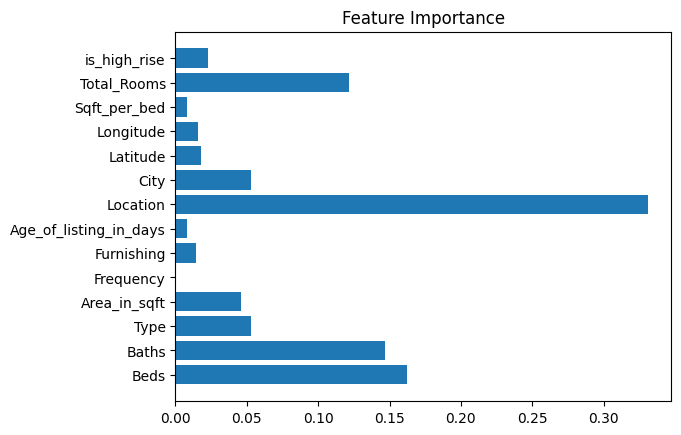

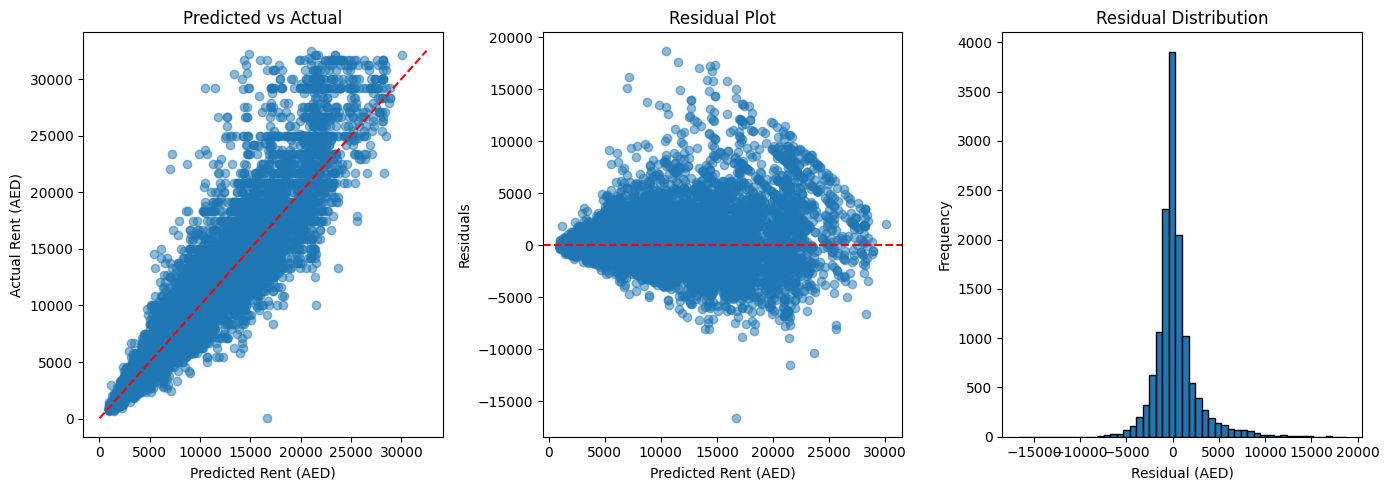

In [16]:
from sklearn.model_selection import RandomizedSearchCV
print("Starting Optimized Regression Training (Log-Scaled & Tuned)...")

# --- STEP 3: HANDLE SKEWNESS ---
# Transform target to log scale
y_reg = np.log1p(df['Monthly_Rent']) 

X_reg = df.drop(['Rent', 'Monthly_Rent', 'Address', 'Posted_date', 'Purpose', 'Rent_per_sqft', 'Rent_category'], axis=1)
cat_cols = ['Location', 'City', 'Type', 'Frequency', 'Furnishing']

X_train_raw, X_test_raw, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_train_reg, X_test_reg = target_encode(X_train_raw, X_test_raw, cat_cols, y_train_reg)

scaler = StandardScaler()
X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

# --- STEP 2: HYPERPARAMETER TUNING ---
# Define the search grid
param_dist = {
    'n_estimators': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 10],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 1, 5]
}

with mlflow.start_run(run_name="Optimized_XGBoost", nested=True):
    xgb_base = XGBRegressor(n_jobs=-1, random_state=42)
    
    # This searches for the best parameters automatically
    search = RandomizedSearchCV(xgb_base,
    param_distributions=param_dist,
    n_iter=10, 
    cv=5, # 5-Fold Cross Validation
    scoring='r2',
    verbose=1)

    search.fit(X_train_reg, y_train_reg)
    print(f"Best CV R2 Score: {search.best_score_:.4f}")

    best_model = search.best_estimator_
    preds_log = best_model.predict(X_test_reg)
    
    # REVERSING THE LOG: Turn values back to AED
    y_test_actual = np.expm1(y_test_reg)
    preds_actual = np.expm1(preds_log)
    
    rmse_aed = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
    r2 = r2_score(y_test_actual, preds_actual)

    # Calculate MAE
    mae = mean_absolute_error(y_test_actual, preds_actual)
    print(f"Mean Absolute Error: AED {mae:,.2f}")
    print(f"This means predictions are off by ±{mae:,.0f} AED on average")
    
    # Log everything to MLflow
    mlflow.log_params(search.best_params_) 
    mlflow.log_metric("rmse_aed", rmse_aed)
    mlflow.log_metric("r2", r2)
    mlflow.log_metric("mae_aed", mae)
    mlflow.sklearn.log_model(best_model, "optimized_model")
    
    print(f"✅ Best Settings Found: {search.best_params_}")
    print(f"Logged to MLflow: RMSE (AED)={rmse_aed:,.2f}, R2={r2:.4f}")

importance = best_model.feature_importances_
plt.barh(range(len(importance)), importance)
plt.yticks(range(len(importance)), X_reg.columns)
plt.title('Feature Importance')
plt.show()

# Residual Analysis
residuals = y_test_actual - preds_actual

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.scatter(preds_actual, y_test_actual, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 'r--')
plt.xlabel('Predicted Rent (AED)')
plt.ylabel('Actual Rent (AED)')
plt.title('Predicted vs Actual')

plt.subplot(1, 3, 2)
plt.scatter(preds_actual, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Rent (AED)')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.subplot(1, 3, 3)
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residual (AED)')
plt.ylabel('Frequency')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()



# Classification Model


Starting Classification Training...


c:\Users\yash2\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:199: UserWarning:

[00:11:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.


2026/01/28 00:11:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged XGBoost Clf Classification: Accuracy=0.8726


2026/01/28 00:11:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged RF Clf Classification: Accuracy=0.8692
Rent Categories:
                        min           max          mean
Rent_category                                          
High           11700.000000  32499.916667  17820.286598
Low                0.000000   5416.666667   3460.411025
Medium          5433.333333  11666.666667   8327.760469


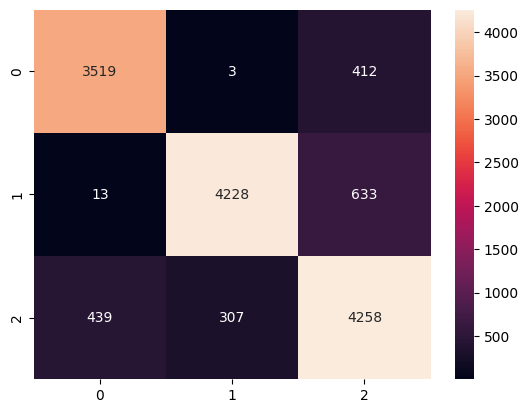

In [17]:
print("\nStarting Classification Training...")
le = LabelEncoder()
y_clf = le.fit_transform(df['Rent_category'])
X_clf = df.drop(['Rent', 'Monthly_Rent', 'Address', 'Posted_date', 'Purpose', 'Rent_per_sqft', 'Rent_category'], axis=1)

X_train_c_raw, X_test_c_raw, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
X_train_clf, X_test_clf = target_encode(X_train_c_raw, X_test_c_raw, cat_cols, pd.Series(y_train_clf))
X_train_clf = scaler.fit_transform(X_train_clf)
X_test_clf = scaler.transform(X_test_clf)

models_clf = {
    "XGBoost Clf": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42) if 'XGBClassifier' in globals() else None,
    "RF Clf": RandomForestClassifier(n_jobs=-1, random_state=42)
}

for name, model in models_clf.items():
    if model is None: continue
    with mlflow.start_run(run_name=f"Clf_{name}", nested=True):
        model.fit(X_train_clf, y_train_clf)
        y_pred = model.predict(X_test_clf)
        
        acc = accuracy_score(y_test_clf, y_pred)
        f1 = f1_score(y_test_clf, y_pred, average='weighted')
       
        mlflow.log_param("model_name", name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        mlflow.sklearn.log_model(model, "model")
        print(f"Logged {name} Classification: Accuracy={acc:.4f}")

print("Rent Categories:")
print(df.groupby('Rent_category')['Monthly_Rent'].agg(['min', 'max', 'mean']))
cm = confusion_matrix(y_test_clf, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## 3. Visualizations

In [ ]:
print("Loading Interactive Locality Explorer...")
localities = sorted(df['Location'].unique())
drop = widgets.Dropdown(options=localities, description='Locality:')
out = widgets.Output()

def update(change):
    with out:
        clear_output(wait=True)
        sub = df[df['Location'] == change['new']]
        print(f"Avg Rent: AED {sub['Monthly_Rent'].mean():,.2f}")
        px.histogram(sub, x="Monthly_Rent", title=f"Rent in {change['new']}").show()

drop.observe(update, 'value')
display(drop, out)
update({'new': localities[0]})

Loading Interactive Locality Explorer...


Dropdown(description='Locality:', options=('Abu Dhabi Gate City (Officers City)', 'Abu Krayyah', 'Abu Samrah',…

Output()

C:\Users\yash2\AppData\Local\Temp\ipykernel_24224\2224877613.py:2: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



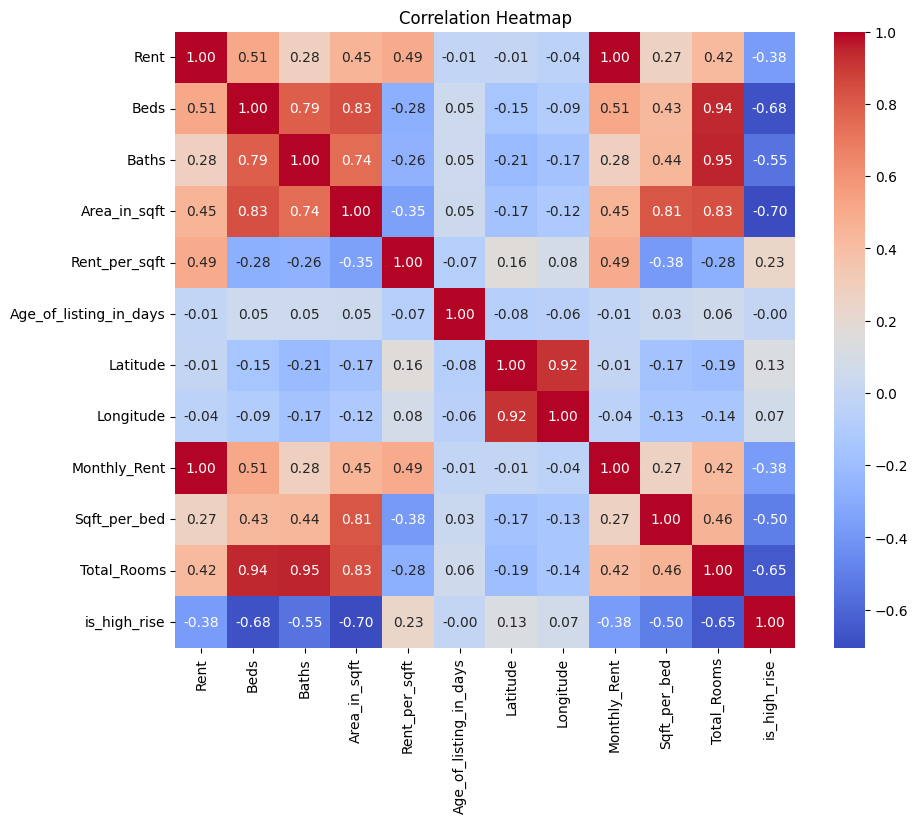

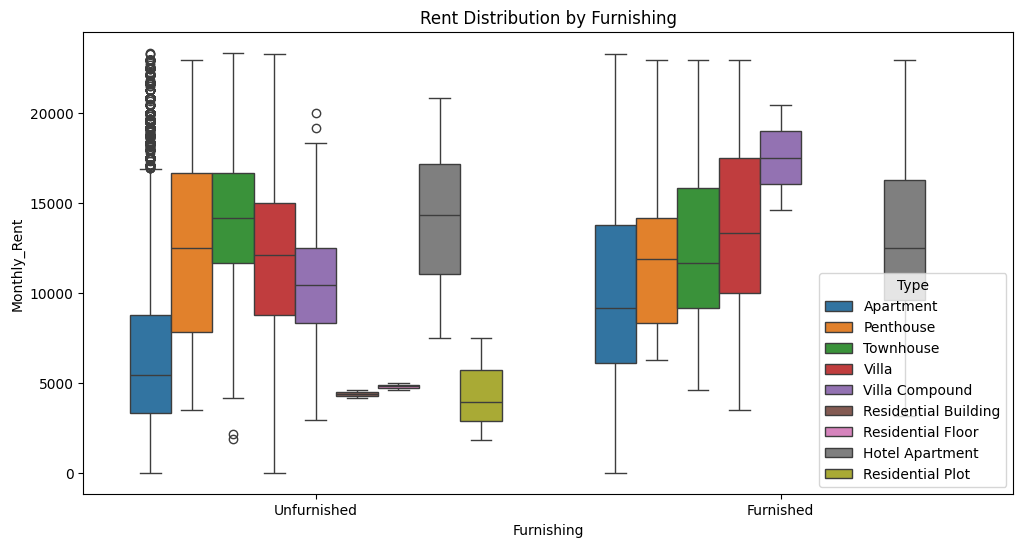

In [19]:
# 3.1 Geographic Map
fig = px.scatter_mapbox(
    df.sample(min(5000, len(df))), 
    lat="Latitude", 
    lon="Longitude", 
    color="Monthly_Rent",
    size="Area_in_sqft",
    hover_name="Location",
    hover_data={"Latitude": False,"Longitude": False,"Monthly_Rent": ":,.2f","Type": True,
                "Beds": True},
    color_continuous_scale=px.colors.cyclical.IceFire,
    zoom=10, height=600, title="Geographical Distribution(English Lables)"
)
#carto-positron style provides English labels without a Mapbox token
fig.update_layout(mapbox_style="carto-positron")
fig.show()

# 3.2 Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 3.3 Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(x='Furnishing', y='Monthly_Rent', hue='Type', data=df[df['Monthly_Rent'] < df['Monthly_Rent'].quantile(0.95)])
plt.title('Rent Distribution by Furnishing')
plt.show()